# Classificação com Boosting - Adaboost

In [354]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import joblib

sns.set_style('whitegrid')

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (classification_report, accuracy_score, precision_score, 
                             recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay)

## Ler dados e preprocessor
- Dados já foram limpos no notebook de Bagging.
- Preprocessor desses dados também já foi realizado.

In [355]:
preprocessor: ColumnTransformer = joblib.load('preprocessor.pkl')

In [356]:
df_leads = pd.read_csv('./dataset/leads.csv')
df_leads.info()

<class 'pandas.DataFrame'>
RangeIndex: 9074 entries, 0 to 9073
Data columns (total 17 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Lead Origin                             9074 non-null   str    
 1   Lead Source                             9074 non-null   str    
 2   Do Not Email                            9074 non-null   int64  
 3   Do Not Call                             9074 non-null   int64  
 4   Converted                               9074 non-null   int64  
 5   TotalVisits                             9074 non-null   float64
 6   Total Time Spent on Website             9074 non-null   int64  
 7   Page Views Per Visit                    9074 non-null   float64
 8   Last Activity                           9074 non-null   str    
 9   Search                                  9074 non-null   int64  
 10  Newspaper Article                       9074 non-null   int64  
 11  X 

## Preparação dos Dados

In [357]:
X = df_leads.drop(columns=['Converted'])
y = df_leads['Converted']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=51)

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(X_train_transformed.shape)
print(X_test_transformed.shape)

(7259, 68)
(1815, 68)


## Treinamento do Modelo
- `learning_rate`: Quanto menor, mais lentamente o aprendizado de um para outro modelo. Dando passos menores, o erro em um modelo para outro pode ser menor. Logo, usar muitos estimadores nesse caso pode levar ao overfitting. Já em casos de passos maiores, pode levar a maior erro de um modelo para outro, o que pode ser bom se os modelos fracos não estiverem cometendo grandes erros.

In [358]:
boosting_model = AdaBoostClassifier(
  estimator=LogisticRegression(),
  n_estimators=50,
  learning_rate=0.5,
  random_state=51,
)

In [359]:
boosting_model.fit(X_train_transformed, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",LogisticRegression()
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",51
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,LogisticRegression,LogisticRegression()
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](50,)","[0.38,0.36,0.28,...,0.48,0.49,0.48]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](50,)","[0.24,0.29,0.48,...,0.04,0.01,0.05]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[LogisticRegre...ate=754760702), LogisticRegre...te=1404930105), LogisticRegre...ate=192037349), LogisticRegre...tate=39519968), ...]"
n_classes_ n_classes_: intThe number of classes.,int,2


## Análise das Métricas

In [360]:
y_pred = boosting_model.predict(X_test_transformed)

In [361]:
accuracy = accuracy_score(y_pred=y_pred, y_true=y_test)
precision = precision_score(y_pred=y_pred, y_true=y_test)
f1 = f1_score(y_pred=y_pred, y_true=y_test)
recall = recall_score(y_pred=y_pred, y_true=y_test)
cr = classification_report(y_pred=y_pred, y_true=y_test, digits=4)

In [362]:
print(f"Acurácia: {accuracy}")
print(f"Precisão: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")

Acurácia: 0.7966942148760331
Precisão: 0.726998491704374
Recall: 0.7194029850746269
F1-Score: 0.7231807951987997


In [363]:
print(cr)

              precision    recall  f1-score   support

           0     0.8368    0.8419    0.8394      1145
           1     0.7270    0.7194    0.7232       670

    accuracy                         0.7967      1815
   macro avg     0.7819    0.7807    0.7813      1815
weighted avg     0.7963    0.7967    0.7965      1815



### Matriz de Confusão

Text(0.5, 1.0, 'Matriz de Confusão')

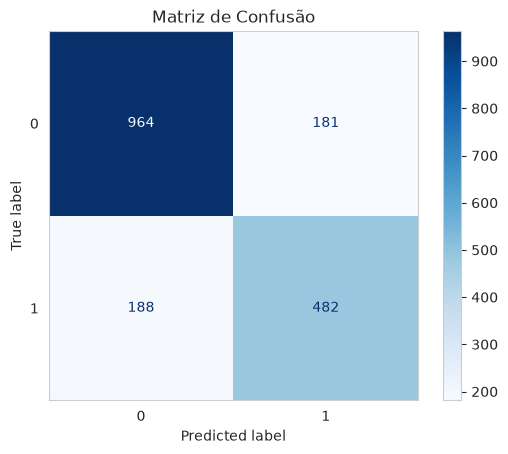

In [364]:
conf_matrix = confusion_matrix(y_pred=y_pred, y_true=y_test)
cmd = ConfusionMatrixDisplay(conf_matrix)
cmd.plot(
  cmap='Blues'
)
plt.grid(visible=False)
plt.title("Matriz de Confusão")

## Importância de Features

In [365]:
importances = [np.abs(estimator.coef_[0]) for estimator in boosting_model.estimators_]
mean_importances = np.mean(importances, axis=0)
mean_importances_percentage = mean_importances / np.sum(mean_importances)
mean_importances_percentage

array([3.19354441e-02, 1.48315854e-02, 1.30659756e-02, 6.84456026e-02,
       2.19796527e-02, 2.90460971e-03, 6.11269270e-03, 1.00662316e-02,
       9.47977476e-03, 1.17434787e-03, 5.08989953e-03, 1.93776648e-02,
       4.91293335e-02, 4.73485843e-02, 1.03827978e-01, 7.35673930e-03,
       3.26811409e-04, 3.69866577e-02, 8.07490968e-03, 2.13581351e-02,
       2.13571952e-04, 2.74788617e-04, 1.69271141e-02, 2.58901369e-02,
       2.55232520e-04, 7.19548527e-02, 8.26630852e-03, 3.01784624e-04,
       2.97782430e-04, 3.09179757e-02, 9.91060996e-04, 6.53093922e-04,
       2.29263518e-04, 3.50696864e-04, 1.73269839e-04, 2.51623834e-03,
       2.10003675e-02, 1.79108747e-02, 5.01408393e-03, 6.94424419e-04,
       2.08335268e-02, 9.42063901e-04, 4.19636923e-03, 1.03069462e-02,
       4.48900682e-02, 1.20616953e-02, 1.03460315e-03, 5.03712901e-02,
       8.00636172e-03, 5.53017164e-03, 6.06608993e-05, 1.64937730e-04,
       3.87035227e-04, 4.65046271e-03, 1.38876150e-03, 6.94424419e-04,
      

In [366]:
feature_names = (
  X.select_dtypes('number').columns.tolist() +
  list(preprocessor.named_transformers_['cat'].get_feature_names_out(X.select_dtypes(include='object').columns.tolist()))
)
feature_names

/tmp/ipykernel_2217106/2572512820.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  list(preprocessor.named_transformers_['cat'].get_feature_names_out(X.select_dtypes(include='object').columns.tolist()))


['Do Not Email',
 'Do Not Call',
 'TotalVisits',
 'Total Time Spent on Website',
 'Page Views Per Visit',
 'Search',
 'Newspaper Article',
 'X Education Forums',
 'Newspaper',
 'Digital Advertisement',
 'Through Recommendations',
 'A free copy of Mastering The Interview',
 'Lead Origin_API',
 'Lead Origin_Landing Page Submission',
 'Lead Origin_Lead Add Form',
 'Lead Origin_Lead Import',
 'Lead Source_Click2call',
 'Lead Source_Direct Traffic',
 'Lead Source_Facebook',
 'Lead Source_Google',
 'Lead Source_Live Chat',
 'Lead Source_NC_EDM',
 'Lead Source_Olark Chat',
 'Lead Source_Organic Search',
 'Lead Source_Pay per Click Ads',
 'Lead Source_Reference',
 'Lead Source_Referral Sites',
 'Lead Source_Social Media',
 'Lead Source_WeLearn',
 'Lead Source_Welingak Website',
 'Lead Source_bing',
 'Lead Source_blog',
 'Lead Source_testone',
 'Lead Source_welearnblog_Home',
 'Lead Source_youtubechannel',
 'Last Activity_Approached upfront',
 'Last Activity_Converted to Lead',
 'Last Activity_

In [367]:
df_features = pd.DataFrame({ 'feature': feature_names, 'importance': mean_importances_percentage })
df_features.sort_values(by='importance', ascending=True, inplace=True)
df_features

,feature,importance
50,Last Activity_View in browser link Clicked,0.000061
58,Last Notable Activity_Form Submitted on Website,0.000164
51,Last Activity_Visited Booth in Tradeshow,0.000165
34,Lead Source_youtubechannel,0.000173
67,Last Notable Activity_View in browser link Cli...,0.000174
...,...,...
12,Lead Origin_API,0.049129
47,Last Activity_SMS Sent,0.050371
3,Total Time Spent on Website,0.068446
25,Lead Source_Reference,0.071955


In [368]:
fig = px.bar(
  df_features,
  x='importance',
  y='feature',
  orientation='h',
  title="Importância Percentual das Features (coeficientes absolutos)"
)

fig.update_layout(height=1280, width=1000)
fig.show()

## Propriedades do Modelo

### Saídas do Modelo

#### Erros dos Estimadores

In [369]:
boosting_model.estimator_errors_

array([0.37994214, 0.3567697 , 0.27777729, 0.32731404, 0.42085102,
       0.32973842, 0.38629634, 0.46934865, 0.40861559, 0.47790283,
       0.44191375, 0.47880896, 0.48939972, 0.4553716 , 0.4627871 ,
       0.48992249, 0.41756073, 0.48944088, 0.47380247, 0.45478829,
       0.48525658, 0.49262669, 0.46875054, 0.47832098, 0.47513615,
       0.48321845, 0.44303304, 0.48762754, 0.49346599, 0.49556662,
       0.48649988, 0.47056333, 0.48793195, 0.4939651 , 0.49665449,
       0.46579172, 0.48785954, 0.47645253, 0.49509879, 0.49754933,
       0.4851179 , 0.48680426, 0.49083921, 0.47429221, 0.49142578,
       0.49571257, 0.4977463 , 0.48052505, 0.49266753, 0.47677941])

#### Pesos dos Estimadores

In [370]:
boosting_model.estimator_weights_

array([0.24489691, 0.29470617, 0.47775695, 0.36017927, 0.15964042,
       0.35468419, 0.23145369, 0.06137966, 0.18484571, 0.04422315,
       0.11669939, 0.04240748, 0.02120374, 0.08949498, 0.07456369,
       0.02015776, 0.16639746, 0.02112138, 0.05244309, 0.09067107,
       0.0294954 , 0.0147477 , 0.06258049, 0.04338524, 0.04976875,
       0.03357572, 0.11443079, 0.02474997, 0.01306876, 0.008867  ,
       0.02700681, 0.05894151, 0.02414078, 0.01207039, 0.00669112,
       0.06852362, 0.02428569, 0.0471298 , 0.00980274, 0.00490137,
       0.029773  , 0.0263976 , 0.01832363, 0.05146096, 0.01715013,
       0.00857506, 0.00450742, 0.03896962, 0.01466599, 0.04647462])

#### Predizer a probabilidade de coversão

In [371]:
boosting_model.classes_

array([0, 1])

In [372]:
boosting_model.predict_proba(X=X_test_transformed)

array([[0.32487124, 0.67512876],
       [0.63334942, 0.36665058],
       [0.63334942, 0.36665058],
       ...,
       [0.69559439, 0.30440561],
       [0.77020615, 0.22979385],
       [0.20125159, 0.79874841]], shape=(1815, 2))